### Load Libraries

In [21]:
# Set working directory
setwd(".")
getwd()

# Load package
library(e1071)
library(ctsmTMB)
library(dplyr)
library(lubridate)
library(readr)
library(ggplot2)
library(data.table)
library(ggplot2)
library(patchwork)

[1] "c:/Users/tamas/OneDrive - Danmarks Tekniske Universitet/Advanced TS/AdvTSA/assignment3"

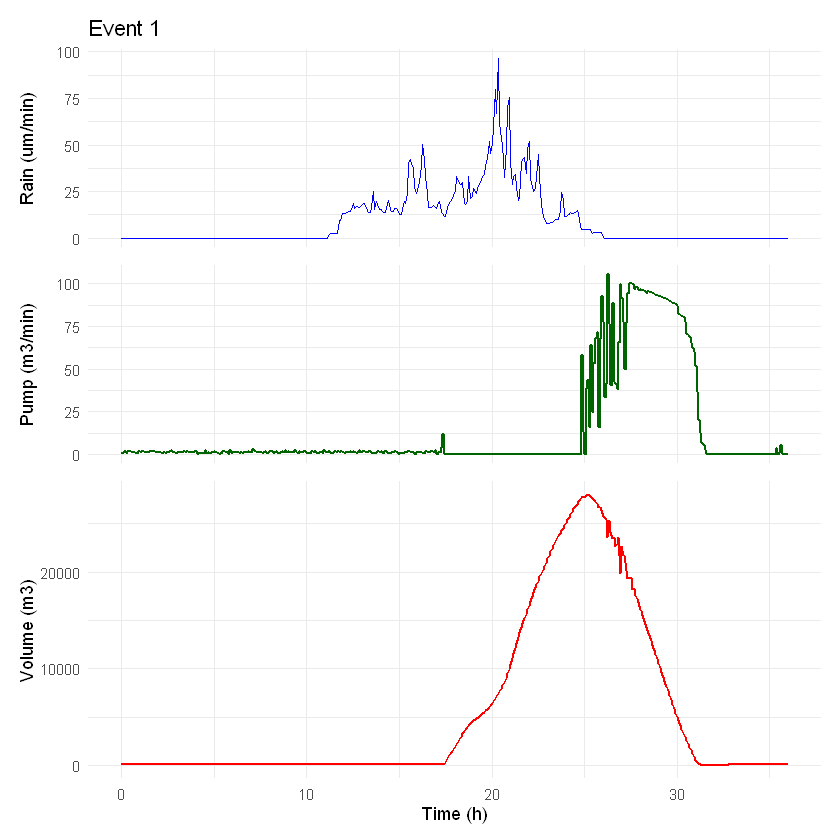

In [22]:

# 1. Load the data
df_large <- read.csv("ex3_largecase.csv")

# 2. FIXED: Rename columns manually to ensure they match the code variables
#    We map: Timestamp -> timestamp, Event_ID -> event, etc.
colnames(df_large) <- c("timestamp", "rainfall", "pumpflow", "volume", "event")

# 3. Preprocess the data (Now this will work)
df_large <- df_large %>%
  mutate(
    timestamp = ymd_hms(timestamp),
    # Global time
    time_h_global = as.numeric(difftime(timestamp, min(timestamp), units = "hours"))
  ) %>%
  group_by(event) %>%  # This will now work because we renamed Event_ID to event
  mutate(
    # Event-relative time
    event_time = as.numeric(difftime(timestamp, min(timestamp), units = "hours"))
  ) %>%
  ungroup()

# 4. Plotting Function
plot_event <- function(evt_id) {
  dat <- filter(df_large, event == evt_id)
  
  p1 <- ggplot(dat, aes(x = event_time, y = rainfall)) +
    geom_line(color = "blue") +
    labs(title = paste("Event", evt_id), y = "Rain (um/min)", x = NULL) + 
    theme_minimal() +
    theme(axis.text.x = element_blank())
  
  p2 <- ggplot(dat, aes(x = event_time, y = pumpflow)) +
    geom_step(color = "darkgreen", linewidth = 0.8) + 
    labs(y = "Pump (m3/min)", x = NULL) + 
    theme_minimal() +
    theme(axis.text.x = element_blank())
  
  p3 <- ggplot(dat, aes(x = event_time, y = volume)) +
    geom_line(color = "red", linewidth = 0.8) +
    labs(y = "Volume (m3)", x = "Time (h)") + 
    theme_minimal()
  
  p1 / p2 / p3 + plot_layout(heights = c(1, 1, 1.5))
}

# Test plotting
print(plot_event(1))

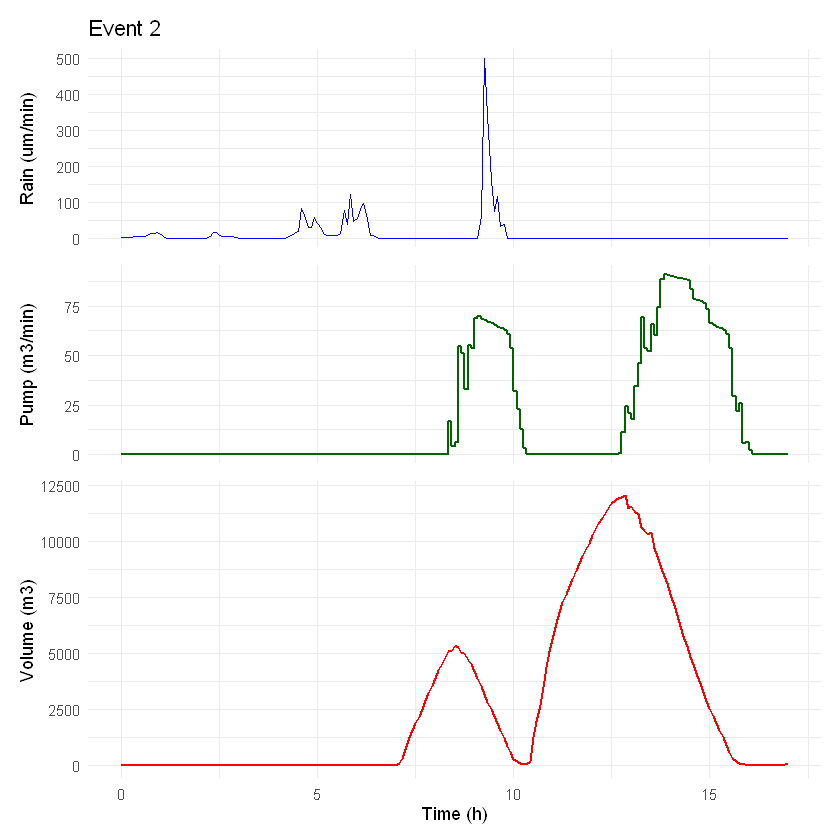

In [23]:
print(plot_event(2))

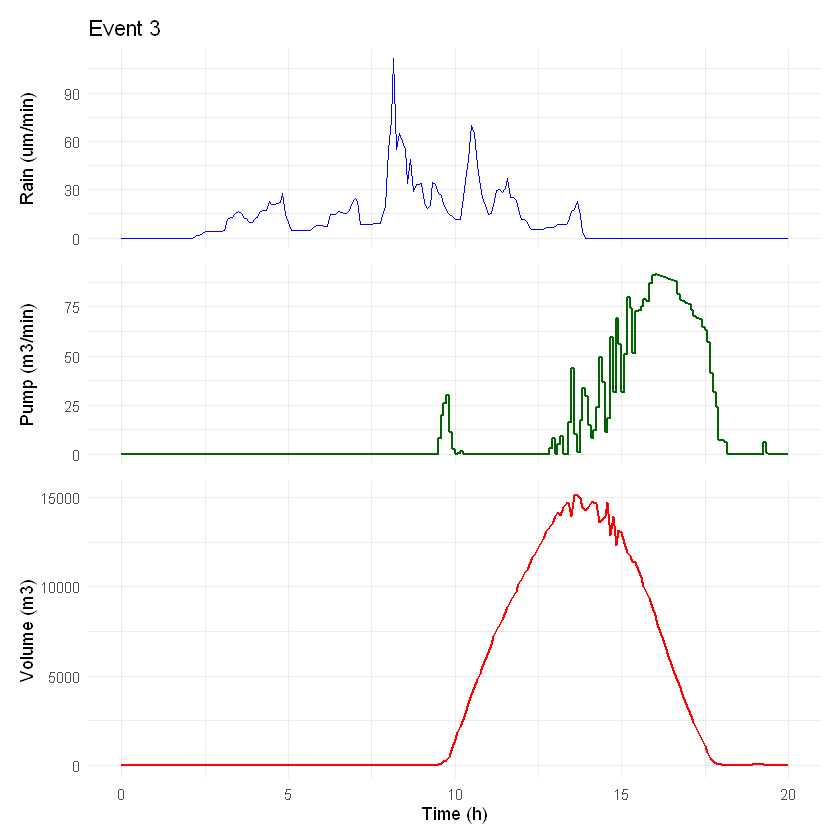

In [24]:
print(plot_event(3))

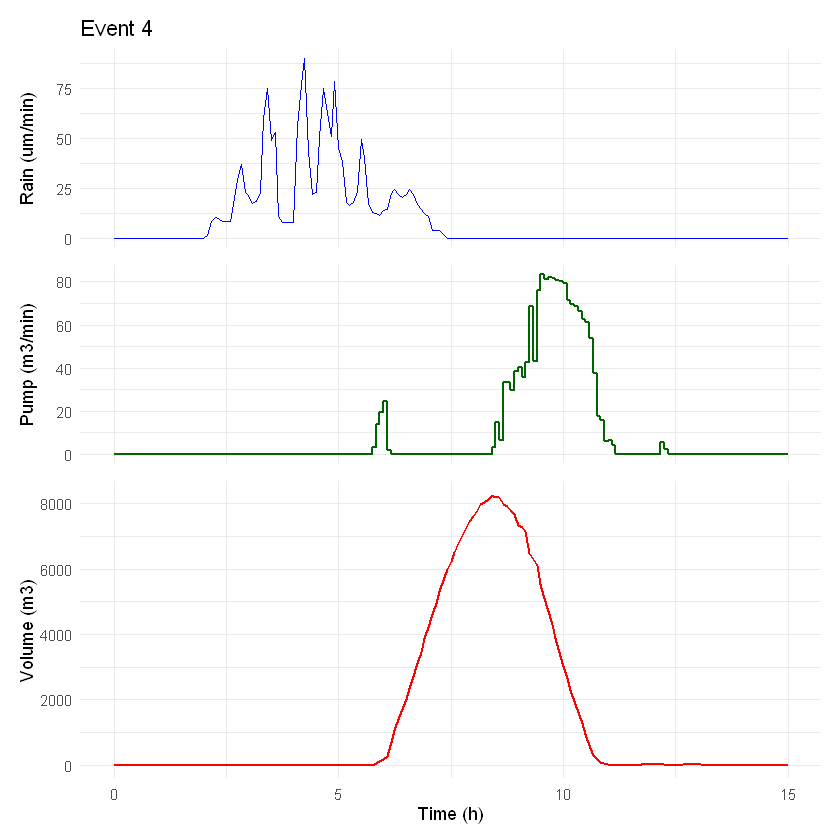

In [25]:
print(plot_event(4))

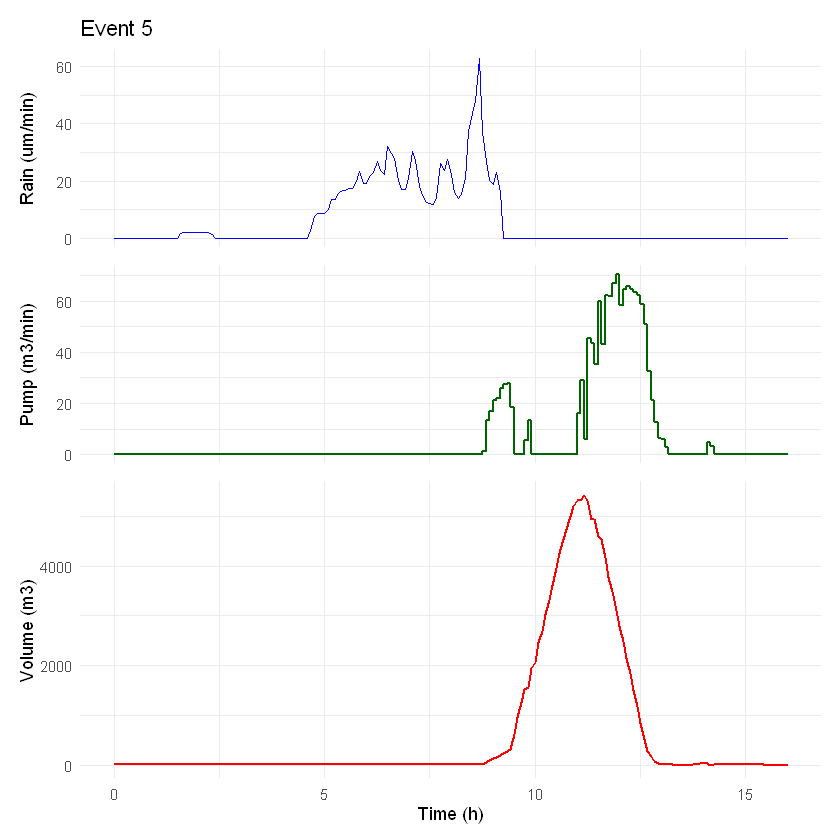

In [26]:
print(plot_event(5))

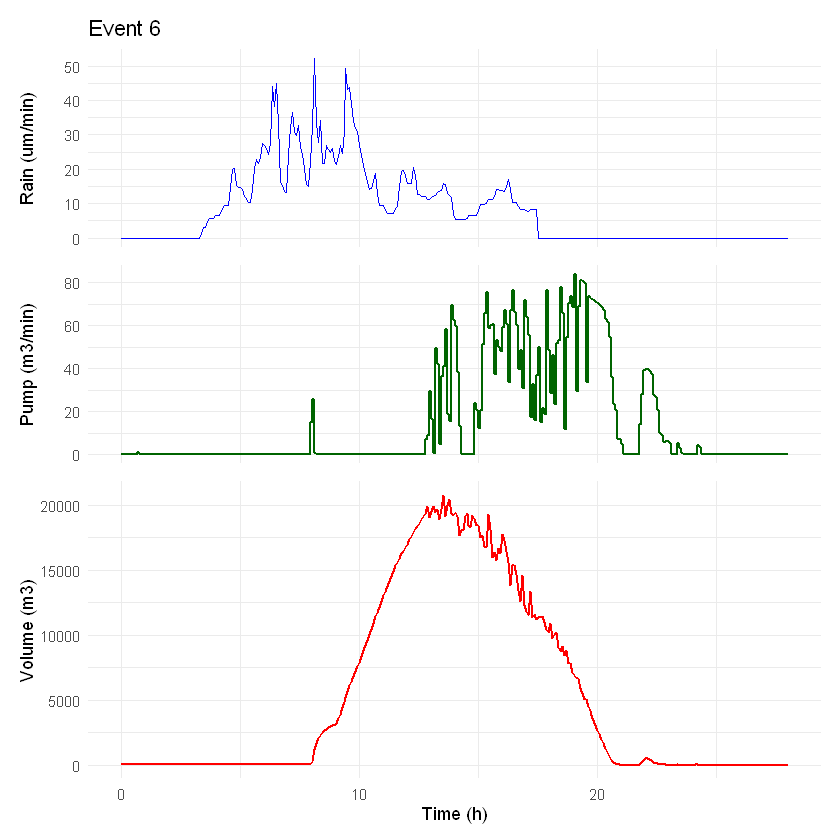

In [27]:
print(plot_event(6))

### 2.3.2 

### 2.3.3

Checking model components...

Checking and setting data...

Constructing objective function and derivative tables...

Checking and setting data...

Constructing objective function and derivative tables...

Minimizing the negative log-likelihood...

Minimizing the negative log-likelihood...



  0:     1731313.5:  10.0000  1.00000  1.00000  5.00000  5.00000 -1.00000 -1.00000 -3.00000 -2.00000
 10:    -6.3276226: 0.00100000  4.79534  3.89571  4.92630  5.00171 -2.48295  1.57204 -3.33052 -1.60111
 20:    -14.025442: 0.0894311  5.66410  4.26053  4.92254  5.01286 -2.34703  1.37110 -3.69155 -1.68736
 30:    -27.766838: 0.259770 0.504007  3.40107  4.90289  5.55314 -2.66971  1.07042 -7.03258 -1.68818
 40:    -30.645878: 0.318030 0.381716  3.41204  4.90272  5.55978 -2.67203 0.966850 -7.05607 -1.68894
 50:    -31.480513: 0.344153 0.340835  3.42904  4.90221  5.55880 -2.67248 0.884641 -7.06028 -1.68925
 60:    -31.573168: 0.349022 0.337203  3.43550  4.90182  5.55637 -2.67231 0.860007 -7.05825 -1.68920
 70:    -31.594856: 0.351396 0.333768  3.43937  4.90122  5.55281 -2.67218 0.846098 -7.05644 -1.68917
 80:    -31.598483: 0.351926 0.333225  3.44107  4.90053  5.54882 -2.67212 0.841206 -7.05523 -1.68908
 90:    -31.599925: 0.351945 0.333068  3.44160  4.89973  5.54438 -2.67214 0.840054 -7.05

	 Optimization finished!:
            Elapsed time: 14.8 seconds.
            The objective value is: -3.440427e+01
            The maximum gradient component is: 5.3e-03
            The convergence message is: relative convergence (4)
            Iterations: 9019
            Evaluations: Fun: 9078 Grad: 9020
            See stats::nlminb for available tolerance/control arguments.

Returning results...

Returning results...

Finished!

Finished!



[1] "---- Estimation Summary (Event 1) ----"
Coefficent Matrix 
               Estimate  Std. Error  t value  Pr(>|t|)    
A              0.764837    0.978419   0.7817  0.434823    
K1             0.512003    0.226650   2.2590  0.024390 *  
K2             1.619134    0.544806   2.9719  0.003128 ** 
alpha          0.122968    0.191826   0.6410  0.521842    
beta          30.000000   54.629623   0.5492  0.583190    
log_sigma1    -8.631185 8968.013554  -0.0010  0.999233    
log_sigma2     0.135721    0.286100   0.4744  0.635471    
log_sigma3   -10.000000  816.683735  -0.0122  0.990236    
log_sigma_y   -1.688582    0.036066 -46.8198 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
$parameters
               Estimate   Std. Error       t value      Pr(>|t|)
A             0.7648374 9.784194e-01  7.817071e-01  4.348230e-01
K1            0.5120029 2.266497e-01  2.259006e+00  2.439021e-02
K2            1.6191342 5.448058e-01  2.971948e+00  3.127678e-03
alpha  

Checking and setting data...

Predicting with R...

Predicting with R...

Returning results...

Finished!

Returning results...

Finished!



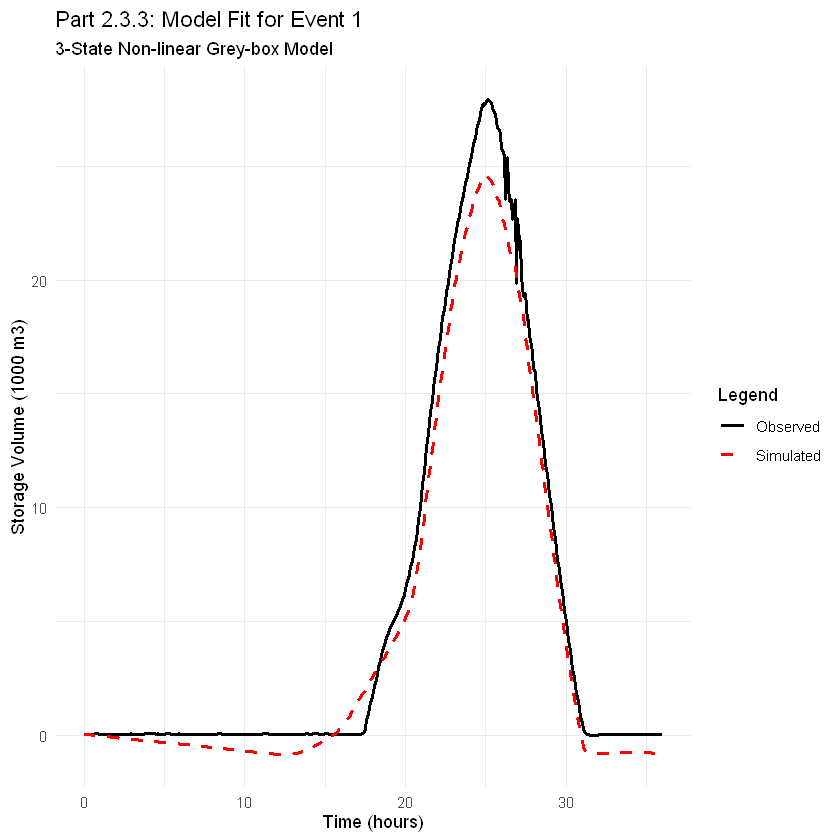

In [28]:
library(ctsmTMB)
library(dplyr)
library(lubridate)
library(ggplot2)

# 1. Load and Clean Data
# -------------------------------------------------------
df_raw <- read.csv("ex3_largecase.csv")

# Fix column names to be consistent (lowercase)
colnames(df_raw) <- c("timestamp", "rainfall", "pumpflow", "volume", "event")

# 2. Preprocess Event 1
# -------------------------------------------------------
# Scaling factor: 1 unit = 1000 m3
S <- 1000 

data_evt1 <- df_raw %>%
  filter(event == 1) %>%
  mutate(
    # Time in hours relative to start
    t = as.numeric(difftime(ymd_hms(timestamp), min(ymd_hms(timestamp)), units = "hours")),
    
    # Observation: Volume scaled to 1000 m^3
    y = volume / S,
    
    # Input: Pump flow converted from m^3/min to (1000 m^3)/hour
    # Calculation: (m3/min * 60 min/hr) / 1000 = m3/hr / 1000
    p = pumpflow * 0.06,
    
    # Input: Rainfall (um/min) - we keep it as is; parameter A absorbs the unit conversion
    r = rainfall
  ) %>%
  select(t, y, p, r)

# 3. Define the Non-linear State Space Model
# -------------------------------------------------------
model <- ctsmTMB$new()

# -- States --
# x1: Ground/Sewer water level (driving state)
# x2: Stormwater Tunnel volume
# x3: Storage Tower volume (Observed)

# -- System Equations (SDEs) --
# x1 acts as a linear reservoir accumulating rain
# x2 receives water from x1 ONLY when x1 > beta (Sigmoid overflow)
# x3 receives water from x2 linearly, and is emptied by pump p

model$addSystem(
  dx1 ~ A * r * dt - (1/K1) * x1 * dt + exp(log_sigma1) * dw1,
  dx2 ~ (1/K1) * x1 * (1 / (1 + exp(-alpha * (x1 - beta)))) * dt - (1/K2) * x2 * dt + exp(log_sigma2) * dw2,
  dx3 ~ (1/K2) * x2 * dt - p * dt + exp(log_sigma3) * dw3
)

# -- Observation Equation --
model$addObs(y ~ x3)

# -- Variance (Log-scale for stability) --
model$setVariance(y ~ exp(log_sigma_y)^2)

# -- Inputs --
model$addInput(r, p)

# -- Initial Parameters --
# Note: Beta (threshold) depends on x1 magnitude. 
# Since x1 is driven by A*r, its scale is unknown but A~1-10 usually puts states in range 1-20.
model$setParameter(
  A           = c(init = 10,   lb = 1e-3, ub = 100),
  K1          = c(init = 1,    lb = 1e-3, ub = 20),
  K2          = c(init = 1,    lb = 1e-3, ub = 20),
  alpha       = c(init = 5,    lb = 0.1,  ub = 30), # Steepness
  beta        = c(init = 5,    lb = 0.1,  ub = 30), # Overflow threshold
  log_sigma1  = c(init = -1,   lb = -10,  ub = 2),
  log_sigma2  = c(init = -1,   lb = -10,  ub = 2),
  log_sigma3  = c(init = -3,   lb = -10,  ub = 1),  # Low noise for storage physics
  log_sigma_y = c(init = -2,   lb = -5,   ub = 1)   # Observation noise
)

# -- Initial State --
# Assume x1, x2 start empty. x3 starts at the observed level.
# Set initial covariance to be small but non-zero.
model$setInitialState(list(c(0, 0, data_evt1$y[1]), diag(0.1, 3)))

# 4. Estimate Parameters
# -------------------------------------------------------
# We use the nlminb optimizer (default)
fit <- model$estimate(data_evt1)

# 5. Report Results
# -------------------------------------------------------
print("---- Estimation Summary (Event 1) ----")
print(summary(fit))

# 6. Plotting the Fit
# -------------------------------------------------------
pred <- model$predict(data_evt1)[[1]]

# Combine for plotting
plot_data <- data.frame(
  Time = data_evt1$t,
  Observed = data_evt1$y,
  Simulated = pred$x3
)

ggplot(plot_data, aes(x = Time)) +
  geom_line(aes(y = Observed, color = "Observed"), linewidth = 1) +
  geom_line(aes(y = Simulated, color = "Simulated"), linewidth = 1, linetype="dashed") +
  scale_color_manual(values = c("Observed" = "black", "Simulated" = "red")) +
  labs(
    title = "Part 2.3.3: Model Fit for Event 1",
    subtitle = "3-State Non-linear Grey-box Model",
    y = "Storage Volume (1000 m3)",
    x = "Time (hours)",
    color = "Legend"
  ) +
  theme_minimal()

### 2.3.4

In [31]:
library(ctsmTMB)
library(dplyr)
library(lubridate)
library(ggplot2)

# ========================================================
# 1. Data Loading & Preprocessing
# ========================================================
df_raw <- read.csv("ex3_largecase.csv")

# 1. Fix column names immediately to avoid "object not found" errors
colnames(df_raw) <- c("timestamp", "rainfall", "pumpflow", "volume", "event")

# 2. Define Scaling Factor
# Volume reaches ~20,000, so we divide by 1000 to keep numbers small
S <- 1000 

# 3. Prepare storage for results
results_list <- list()
fits_list <- list()

# ========================================================
# 2. Loop Through Events (1 to 6)
# ========================================================

for (evt_id in 1:6) {
  
  cat(paste0("\n==================================\n"))
  cat(paste0("Starting Estimation for Event: ", evt_id, "\n"))
  
  # --- 2.1 Prepare Single Event Data ---
  data_evt <- df_raw %>%
    filter(event == evt_id) %>%
    mutate(
      # Time in hours, starting from 0 for this specific event
      t = as.numeric(difftime(ymd_hms(timestamp), min(ymd_hms(timestamp)), units = "hours")),
      
      # Observations and Inputs (Scaled)
      y = volume / S,            # Scaled Volume
      p = pumpflow * 0.06,       # m3/min -> 1000 m3/h
      r = rainfall               # Rainfall (um/min)
    ) %>%
    select(t, y, p, r)
  
  # --- 2.2 Define Model (Must be re-initialized every loop) ---
  model <- ctsmTMB$new()
  
  # System Equations (3-State Non-linear Overflow)
  # x1: Ground/Sewer | x2: Tunnel | x3: Storage Tower
  model$addSystem(
    dx1 ~ A * r * dt - (1/K1) * x1 * dt + exp(log_sigma1) * dw1,
    dx2 ~ (1/K1) * x1 * (1 / (1 + exp(-alpha * (x1 - beta)))) * dt - (1/K2) * x2 * dt + exp(log_sigma2) * dw2,
    dx3 ~ (1/K2) * x2 * dt - p * dt + exp(log_sigma3) * dw3
  )
  
  # Observation & Variance
  model$addObs(y ~ x3)
  model$setVariance(y ~ exp(log_sigma_y)^2)
  model$addInput(r, p)
  
  # --- 2.3 Parameter Bounds & Initial Values ---
  # Robust bounds are crucial for separate fitting as some events may be short
  model$setParameter(
    A           = c(init = 10,   lb = 0.1, ub = 150),
    K1          = c(init = 2,    lb = 0.01, ub = 50),
    K2          = c(init = 2,    lb = 0.01, ub = 50),
    alpha       = c(init = 5,    lb = 0.1,  ub = 30), # Restrict steepness
    beta        = c(init = 5,    lb = 0.1,  ub = 50),
    
    # Noise parameters (Log scale)
    log_sigma1  = c(init = -1,   lb = -15,  ub = 3),
    log_sigma2  = c(init = -1,   lb = -15,  ub = 3),
    log_sigma3  = c(init = -3,   lb = -15,  ub = 1),
    
    # Force a noise floor if necessary (as per tips)
    log_sigma_y = c(init = -2,   lb = -3,   ub = 2)
  )
  
  # Initial State
  # Assume internal states (x1, x2) are empty; x3 matches observation
  model$setInitialState(list(c(0, 0, data_evt$y[1]), diag(1, 3)))
  
  # --- 2.4 Estimation with Error Handling ---
  fit_result <- try(model$estimate(data_evt), silent = FALSE)
  
  if (!inherits(fit_result, "try-error")) {
    cat("--> Converged successfully.\n")
    
    # Extract parameters - convert to plain numeric vector using as.numeric and unname
    pars <- as.numeric(unname(fit_result$par.fixed))
    
    # Manually calculate AIC (AIC = 2k - 2ln(L))
    k <- length(pars)
    logL <- fit_result$nll * (-1)  # nll is negative log-likelihood, so logL = -nll
    aic_val <- 2 * k - 2 * logL
    
    # Store results
    fits_list[[evt_id]] <- fit_result
    results_list[[evt_id]] <- data.frame(
      Event = evt_id,
      A = pars[1],
      K1 = pars[2],
      K2 = pars[3],
      alpha = pars[4],
      beta = pars[5],
      log_sigma1 = pars[6],
      log_sigma2 = pars[7],
      log_sigma3 = pars[8],
      log_sigma_y = pars[9],
      LogLik = logL,
      AIC = aic_val,
      row.names = NULL
    )
    
  } else {
    cat("--> Failed to converge for Event", evt_id, "\n")
  }
}


Starting Estimation for Event: 1


Checking model components...

Checking and setting data...

Constructing objective function and derivative tables...

Checking and setting data...

Constructing objective function and derivative tables...

Minimizing the negative log-likelihood...

Minimizing the negative log-likelihood...



  0:     1578316.0:  10.0000  2.00000  2.00000  5.00000  5.00000 -1.00000 -1.00000 -3.00000 -2.00000
 10:    -5.1095963: 0.100000  1.16625  11.7099  7.14124  4.73922 -4.46228  2.73910 -5.45707 -1.64146
 20:    -19.383642: 0.333180 0.351674  11.9381  6.80053  4.72417 -4.43401  2.27666 -5.52054 -1.68775
 30:    -24.379736: 0.600436 0.187049  11.8837  6.87326  4.74105 -4.44080  2.19743 -5.50694 -1.68925
 40:    -25.534887: 0.706443 0.153988  11.8883  6.85910  4.73921 -4.44193  2.14568 -5.50673 -1.69151
 50:    -25.660329: 0.723858 0.149634  11.8836  6.86436  4.74124 -4.44242  2.13802 -5.50578 -1.69070
 60:    -25.766008: 0.742106 0.145517  11.8762  6.87143  4.74636 -4.44327  2.13127 -5.50430 -1.69159
 70:    -25.852295: 0.758285 0.142273  11.8677  6.87238  4.75962 -4.44420  2.12361 -5.50335 -1.69121
 80:    -25.909046: 0.770072 0.140209  11.8559  6.87583  4.77682 -4.44535  2.11825 -5.50201 -1.69072
 90:    -25.950246: 0.779193 0.138794  11.8430  6.88092  4.79532 -4.44657  2.11410 -5.50047

	 Optimization finished!:
            Elapsed time: 0.51 seconds.
            The objective value is: -3.29164e+01
            The maximum gradient component is: 1.4e+00
            The convergence message is: relative convergence (4)
            Iterations: 217
            Evaluations: Fun: 264 Grad: 218
            See stats::nlminb for available tolerance/control arguments.

Returning results...

Returning results...

Finished!

Finished!



--> Converged successfully.

Starting Estimation for Event: 2


...

--> Converged successfully.

Starting Estimation for Event: 6


Checking model components...

Checking and setting data...

Constructing objective function and derivative tables...

Checking and setting data...

Constructing objective function and derivative tables...

Minimizing the negative log-likelihood...

Minimizing the negative log-likelihood...



  0:     763635.19:  10.0000  2.00000  2.00000  5.00000  5.00000 -1.00000 -1.00000 -3.00000 -2.00000
 10:     185.93541: 0.100000  6.57558  6.66559  5.01294  4.92287 -4.33927  2.17929 -6.64452 -1.05531
 20:     185.40305: 0.100000  8.92041  3.96132  5.70700  5.91152 -3.99819  1.74820 -7.02934 -1.08441
 30:     184.94971: 0.120810  10.2758  2.22409  6.46316  6.82767 -3.38884  1.18453 -7.82414 -1.07855
 40:     179.93129: 0.100000  1.84540  1.24674  7.55951  3.14272 -1.93606 0.673507 -9.98341 -1.08348
 50:     169.49165: 0.178254  2.48810 0.292898  7.99714  7.20864 -1.44328 -0.535851 -10.6444 -1.01779
 60:     166.02735: 0.187443  2.81977 0.0988515  8.87224  8.83007 -1.92150 -0.691014 -9.90360 -1.12015
 70:     164.86520: 0.184428  2.82165 0.104005  14.3807  8.69513 -3.70241 -0.697616 -7.11974 -1.11268
 80:     164.85947: 0.184405  2.82223 0.104490  14.3873  8.69571 -3.70448 -0.697629 -7.11653 -1.11267
 90:     164.85480: 0.184387  2.82275 0.104876  14.3938  8.69629 -3.70655 -0.697641 -7

	 Optimization finished!:
            Elapsed time: 0.76 seconds.
            The objective value is: 1.630749e+02
            The maximum gradient component is: 1.5e-02
            The convergence message is: relative convergence (4)
            Iterations: 448
            Evaluations: Fun: 516 Grad: 449
            See stats::nlminb for available tolerance/control arguments.

Returning results...

Returning results...

Finished!

Finished!



--> Converged successfully.


[1] "---- Parameter Estimates (Separate Fitting) ----"
  Event     A     K1    K2  alpha   beta log_sigma1 log_sigma2 log_sigma3
1     1 0.969  0.495 1.690  0.100 39.685     -5.459      0.173    -13.380
2     2 0.136  2.481 0.695 30.000  4.965     -3.910      0.798     -2.767
3     3 0.175  3.826 0.260 30.000 13.455     -1.856     -1.441    -15.000
4     4 0.266  5.497 0.718 30.000 23.219     -3.859     -1.421    -15.000
5     5 0.493 11.282 0.385  7.776 36.085     -8.508     -2.399    -15.000
6     6 0.185  2.843 0.150 30.000  8.791     -7.891     -7.164     -0.696
  log_sigma_y   LogLik      AIC
1      -1.688   32.916  -47.833
2      -3.000  151.355 -284.711
3      -1.877   69.184 -120.369
4      -3.000  280.016 -542.033
5      -3.000  320.623 -623.247
6      -1.168 -163.075  344.150


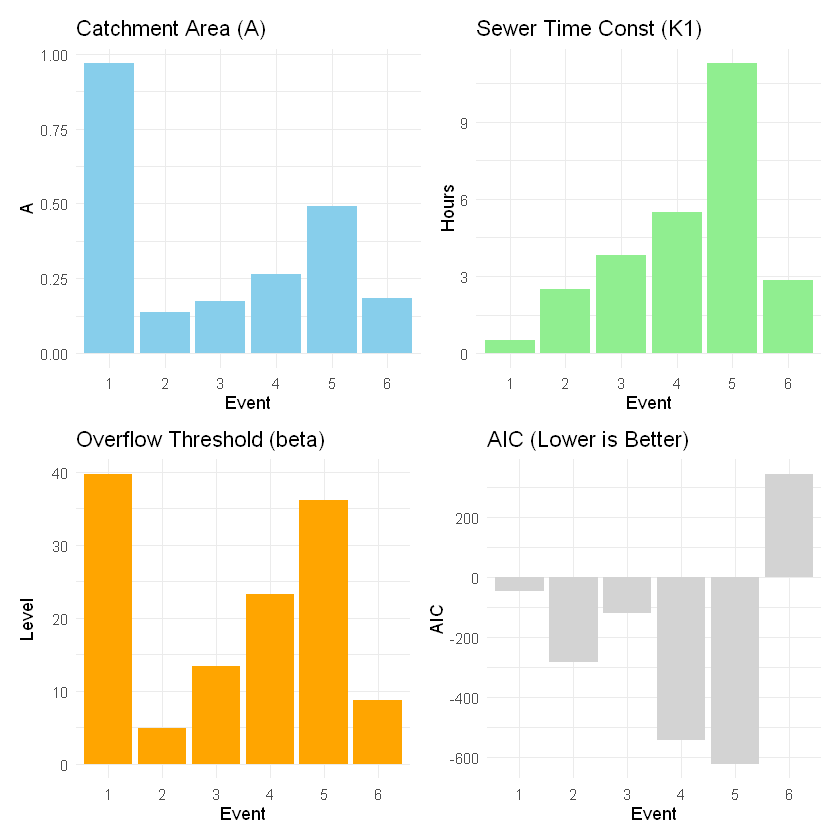

In [32]:
# --- Step 1: Convert results list to a clean Data Frame ---
if (length(results_list) > 0) {
  
  # Combine the list into a data frame
  final_df <- bind_rows(results_list)
  
  # Convert columns to numeric properly (preserving data frame structure)
  final_df <- final_df %>% mutate(across(everything(), as.numeric))
  final_df$Event <- as.integer(final_df$Event)
  
  print("---- Parameter Estimates (Separate Fitting) ----")
  print(round(final_df, 3))
  
  # --- Step 2: Plotting using ggplot2 + patchwork (already loaded in the notebook) ---
  # Order by Event and make a factor for plotting
  final_df <- final_df[order(final_df$Event), ]
  final_df$Event_f <- factor(final_df$Event, levels = unique(final_df$Event))
  
  p1 <- ggplot(final_df, aes(x = Event_f, y = A)) +
  geom_col(fill = "skyblue") +
  labs(title = "Catchment Area (A)", x = "Event", y = "A") +
  theme_minimal()
  
  p2 <- ggplot(final_df, aes(x = Event_f, y = K1)) +
  geom_col(fill = "lightgreen") +
  labs(title = "Sewer Time Const (K1)", x = "Event", y = "Hours") +
  theme_minimal()
  
  p3 <- ggplot(final_df, aes(x = Event_f, y = beta)) +
  geom_col(fill = "orange") +
  labs(title = "Overflow Threshold (beta)", x = "Event", y = "Level") +
  theme_minimal()
  
  p4 <- ggplot(final_df, aes(x = Event_f, y = AIC)) +
  geom_col(fill = "lightgray") +
  labs(title = "AIC (Lower is Better)", x = "Event", y = "AIC") +
  theme_minimal()
  
  # Arrange plots in a 2x2 grid
  (p1 | p2) / (p3 | p4)
  
} else {
  print("No events converged, cannot plot.")
}